In [1]:
import pandas as pd 
import numpy as np 
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')

In [2]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [3]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [4]:
df.dtypes


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
df['TotalCharges']= pd.to_numeric(df['TotalCharges'] , errors = 'coerce')

In [6]:
df['TotalCharges'].isna().sum()

np.int64(11)

In [7]:
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [9]:
df['TotalCharges'].isna().sum()

np.int64(0)

In [10]:
df.isna().sum().sum()

np.int64(0)

In [11]:
df = df.drop('customerID' , axis = 1)

In [12]:
df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No


In [13]:
df.isna().sum().sum()

np.int64(0)

In [14]:
df['Churn_Flag'] = (df['Churn'] =='Yes').astype(int)

In [15]:
average = df.groupby('Contract')['Churn_Flag'].mean()

In [16]:
average


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn_Flag, dtype: float64

In [17]:
averageCitizen = df.groupby('SeniorCitizen')['Churn_Flag'].mean()

In [18]:
averageCitizen

SeniorCitizen
0    0.236062
1    0.416813
Name: Churn_Flag, dtype: float64

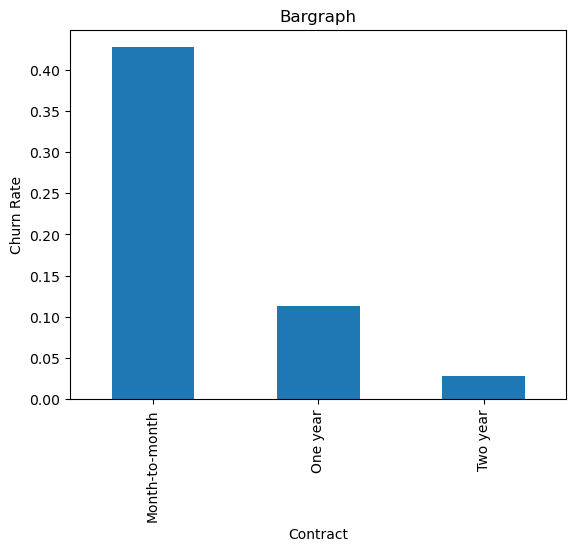

In [19]:
import matplotlib.pyplot as plt 
plt.title('Bargraph')
average.plot(kind = 'bar')
plt.ylabel('Churn Rate')
plt.show()


In [20]:
averageTech = df.groupby('TechSupport')['Churn_Flag'].mean()
averageTech

TechSupport
No                     0.416355
No internet service    0.074050
Yes                    0.151663
Name: Churn_Flag, dtype: float64

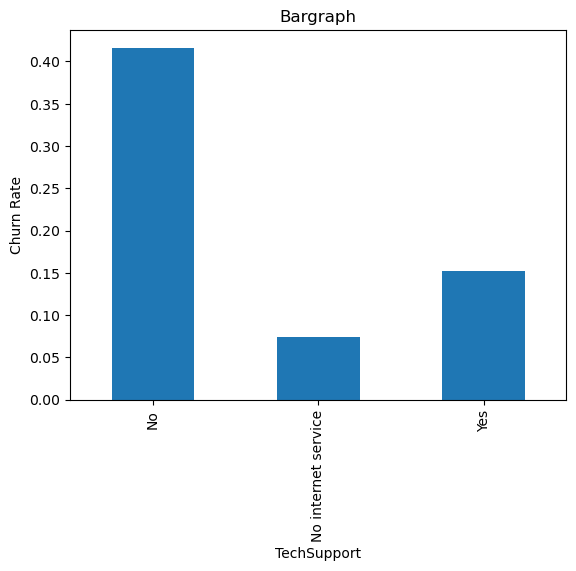

In [21]:
plt.title('Bargraph')
averageTech.plot(kind = 'bar')
plt.ylabel('Churn Rate')
plt.show()


In [22]:
remaining_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                   'StreamingTV', 'StreamingMovies', 'PaymentMethod',
                   'InternetService', 'PaperlessBilling']
for col in remaining_cols:
    
    print(df.groupby(col)['Churn_Flag'].mean())
    

OnlineSecurity
No                     0.417667
No internet service    0.074050
Yes                    0.146112
Name: Churn_Flag, dtype: float64
OnlineBackup
No                     0.399288
No internet service    0.074050
Yes                    0.215315
Name: Churn_Flag, dtype: float64
DeviceProtection
No                     0.391276
No internet service    0.074050
Yes                    0.225021
Name: Churn_Flag, dtype: float64
StreamingTV
No                     0.335231
No internet service    0.074050
Yes                    0.300702
Name: Churn_Flag, dtype: float64
StreamingMovies
No                     0.336804
No internet service    0.074050
Yes                    0.299414
Name: Churn_Flag, dtype: float64
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn_Flag, dtype: float64
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.07

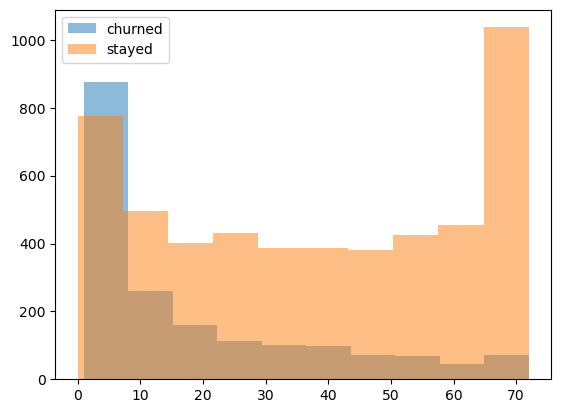

In [23]:
churned = df[df['Churn'] == 'Yes']
stayed = df[df['Churn'] == 'No']
plt.hist(churned['tenure'] , alpha = 0.5 , label = 'churned')
plt.hist(stayed['tenure'] , alpha = 0.5 , label = 'stayed')
plt.legend()
plt.show()

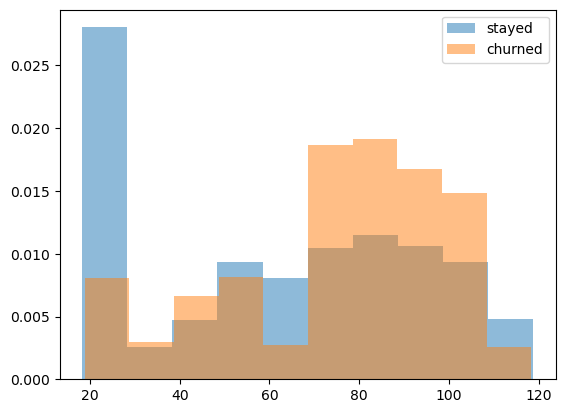

In [24]:
plt.hist(stayed['MonthlyCharges'] , alpha = 0.5 , label = 'stayed' , density = True)
plt.hist(churned['MonthlyCharges'] , alpha = 0.5 , label = 'churned' , density = True)
plt.legend()
plt.show()



In [25]:
#feature engineering 
X = df.drop(columns = ['Churn_Flag' , 'Churn' ], axis = 1)
y = df['Churn_Flag']

categorical_columns = X.select_dtypes(include = 'object').columns


In [26]:
categorical_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [27]:
numerical_columns = X.select_dtypes(exclude = 'object').columns
numerical_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [28]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size = 0.2 , stratify = y , random_state = 42)

In [29]:
print(y_train.value_counts(normalize = True))
y_test.value_counts(normalize = True)

Churn_Flag
0    0.734647
1    0.265353
Name: proportion, dtype: float64


Churn_Flag
0    0.734564
1    0.265436
Name: proportion, dtype: float64

In [30]:
from sklearn.preprocessing import StandardScaler , OneHotEncoder 
from sklearn.compose import ColumnTransformer 
preprocessor = ColumnTransformer(transformers = [
('num' , StandardScaler() , numerical_columns),
('cat' , OneHotEncoder() , categorical_columns) 
])

In [31]:
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression 
model = LogisticRegression()

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

In [33]:
model.fit(X_train , y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [34]:
y_pred = model.predict(X_test)

In [35]:
y_pred

array([0, 1, 0, ..., 0, 0, 0], shape=(1409,))

In [36]:
from sklearn.metrics import classification_report 
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [37]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg/pos


In [38]:
print(scale_pos_weight)

2.768561872909699


In [39]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [40]:
from xgboost import XGBClassifier 
xgb_model = Pipeline([('prep' , preprocessor) , 
                     ('clf' , XGBClassifier(scale_pos_weight = scale_pos_weight , eval_metric = 'logloss'))
                     ])

In [41]:
xgb_model.fit(X_train , y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [42]:
y_pred_xg = xgb_model.predict(X_test)
print(classification_report(y_test , y_pred_xg))

              precision    recall  f1-score   support

           0       0.87      0.79      0.82      1035
           1       0.53      0.66      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.78      0.75      0.76      1409



In [43]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.


In [44]:
X_test_transformed = xgb_model.named_steps['prep'].transform(X_test)

In [45]:
feature_names = xgb_model.named_steps['prep'].get_feature_names_out()

In [46]:
#shap - tells why the model made those decisions 
#step1 
xgb = xgb_model.named_steps['clf']

In [47]:
X_test_transformed = xgb_model.named_steps['prep'].transform(X_test)
feature_names = xgb_model.named_steps['prep'].get_feature_names_out()

In [48]:
import shap

In [49]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer(X_test_transformed)

In [50]:
shap_values.feature_names = feature_names

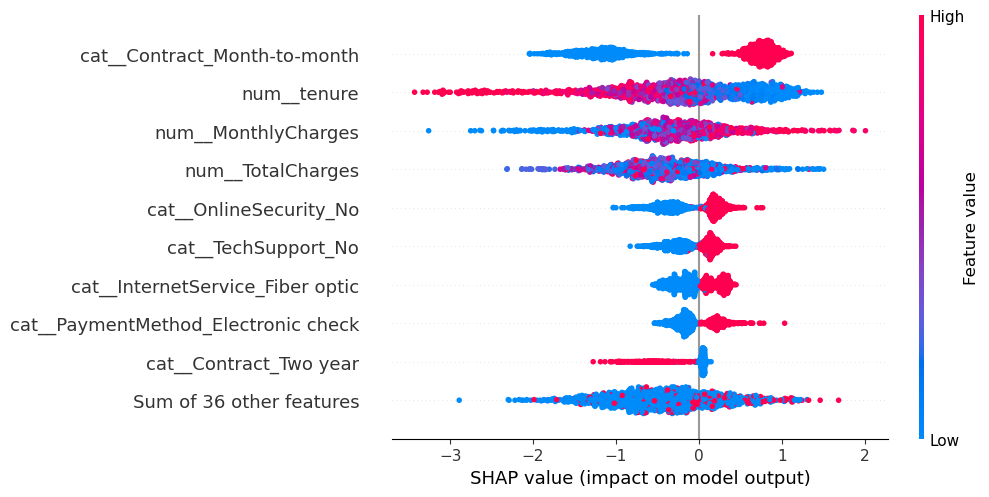

In [51]:
shap.plots.beeswarm(shap_values)

In [52]:
import numpy as np
import shap

print(np.__version__)
print(shap.__version__)

2.2.6
0.51.0


In [53]:
pip install --upgrade shap

Note: you may need to restart the kernel to use updated packages.
